# 05 — Comparação e avaliação final
**Classificação de gênero musical — GTZAN / CNN sobre espectrogramas Mel**

Consolida os modelos do projeto e realiza o **experimento 3**: comparar a **fonte de
entrada** — espectrogramas Mel gerados via librosa (3 s) vs. as **imagens PNG prontas** do
dataset (30 s). Para isolar o efeito da fonte, aplica-se às PNGs a **mesma** melhor
abordagem (extração de features com MobileNetV2 + cabeça densa) usada no notebook 04.

In [1]:
import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

from src import config as C
from src import preprocess, models, evaluate

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
models.set_seeds(C.SEED)

## 1. Resultados já obtidos

Recuperamos as métricas da baseline (notebook 03) e da transferência sobre espectrogramas
librosa (notebook 04), registradas em `models/results.json`.

In [2]:
results = json.loads((C.MODELS_DIR / "results.json").read_text())
for k, v in results.items():
    print(f"  {k:35s}: acc={v['accuracy']:.4f}, f1={v['f1_macro']:.4f}")

  baseline_cnn (mel 3s)              : acc=0.5504, f1=0.5332
  transfer_mobilenetv2 (mel 3s)      : acc=0.7121, f1=0.7065


## 2. Experimento 3 — fonte de entrada: PNGs prontos

Extraímos embeddings da MobileNetV2 para as imagens PNG (128×128×3, clipe inteiro de 30 s) e
treinamos a mesma cabeça densa. **Atenção ao confundimento:** as PNGs representam 30 s
inteiros (1 imagem/música, 150 de teste), enquanto o caminho librosa usa segmentos de 3 s
(1497 de teste) — a comparação reflete *fonte + granularidade*.

In [3]:
img = preprocess.load_dataset("img")

if preprocess.is_cached("img_emb"):
    print("Embeddings das PNGs em cache — carregando.")
    img_emb = preprocess.load_dataset("img_emb")
else:
    print("Extraindo embeddings das PNGs...")
    extractor = models.build_mobilenet_extractor(input_shape=(C.IMAGE_SIZE[1], C.IMAGE_SIZE[0], 3))
    img_emb = {}
    for split in preprocess.SPLITS:
        X, y = img[split]
        feats = extractor.predict(X, batch_size=64, verbose=0)
        img_emb[split] = (feats.astype(np.float32), y)
    preprocess.save_dataset(img_emb, "img_emb")

Etr, ytr = img_emb["train"]
Eva, yva = img_emb["val"]
Ete, yte = img_emb["test"]
print("Embeddings PNG -> treino:", Etr.shape, "| val:", Eva.shape, "| teste:", Ete.shape)

Extraindo embeddings das PNGs...


      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/9406464 ━━━━━━━━━━━━━━━━━━━━ 57s 6us/step

  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 45s 5us/step

  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 42s 5us/step

...

4308992/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

5832704/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

8044544/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Embeddings PNG -> treino: (699, 1280) | val: (150, 1280) | teste: (150, 1280)


In [4]:
MODEL_PATH = C.MODELS_DIR / "transfer_png_head.keras"
HIST_PATH = C.MODELS_DIR / "transfer_png_history.json"

if MODEL_PATH.exists() and HIST_PATH.exists():
    print("Cabeça (PNG) em cache — carregando.")
    head = keras.models.load_model(MODEL_PATH)
else:
    head = models.build_transfer_head(input_dim=Etr.shape[1])
    h = head.fit(Etr, ytr, validation_data=(Eva, yva),
                 epochs=100, batch_size=64,
                 callbacks=models.default_callbacks(patience=10), verbose=2)
    head.save(MODEL_PATH)
    evaluate.save_history(h, HIST_PATH)

res_png = evaluate.evaluate_model(head, Ete, yte)
print(f"\nPNG 30s -> Acurácia (teste): {res_png['accuracy']:.4f} | F1 macro: {res_png['f1_macro']:.4f}")
results = evaluate.append_result("transfer_mobilenetv2 (png 30s)", res_png["accuracy"], res_png["f1_macro"])

Epoch 1/100


11/11 - 2s - 180ms/step - accuracy: 0.2389 - loss: 2.2979 - val_accuracy: 0.4733 - val_loss: 1.7063 - learning_rate: 0.0010


Epoch 2/100


11/11 - 0s - 15ms/step - accuracy: 0.4006 - loss: 1.6559 - val_accuracy: 0.5333 - val_loss: 1.4629 - learning_rate: 0.0010


Epoch 3/100


...

Epoch 37/100


11/11 - 0s - 19ms/step - accuracy: 0.8612 - loss: 0.4756 - val_accuracy: 0.6800 - val_loss: 1.0364 - learning_rate: 1.5625e-05


Epoch 38/100


11/11 - 0s - 19ms/step - accuracy: 0.8712 - loss: 0.4689 - val_accuracy: 0.6733 - val_loss: 1.0366 - learning_rate: 1.0000e-05



PNG 30s -> Acurácia (teste): 0.6333 | F1 macro: 0.6300


              precision    recall  f1-score   support

       blues      0.625     0.667     0.645        15
   classical      0.778     0.933     0.848        15
     country      0.500     0.400     0.444        15
       disco      0.353     0.400     0.375        15
      hiphop      0.700     0.933     0.800        15
        jazz      0.692     0.600     0.643        15
       metal      0.917     0.733     0.815        15
         pop      0.778     0.467     0.583        15
      reggae      0.600     0.600     0.600        15
        rock      0.500     0.600     0.545        15

    accuracy                          0.633       150
   macro avg      0.644     0.633     0.630       150
weighted avg      0.644     0.633     0.630       150



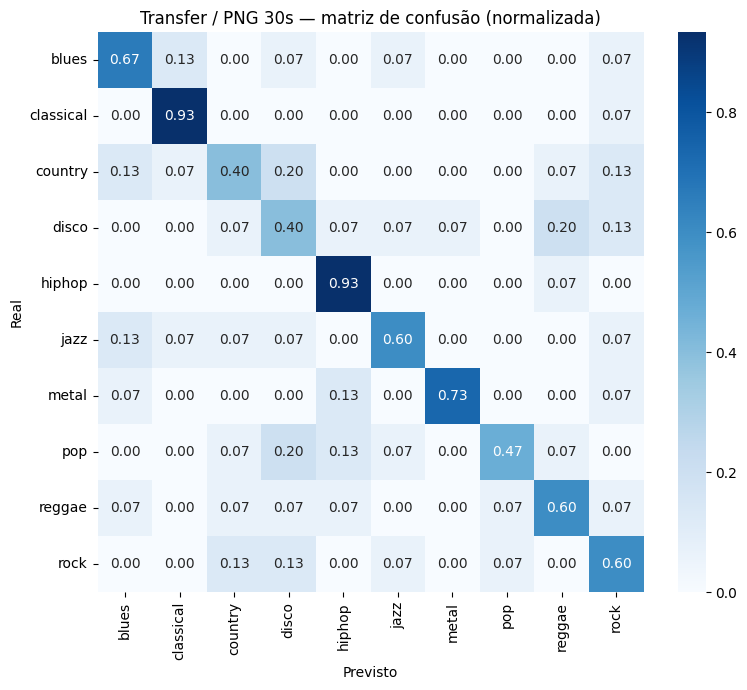

In [5]:
evaluate.print_report(yte, res_png["y_pred"])
evaluate.plot_confusion_matrix(yte, res_png["y_pred"], normalize=True,
                               title="Transfer / PNG 30s — matriz de confusão (normalizada)")
plt.show()

## 3. Quadro comparativo final

In [6]:
order = ["baseline_cnn (mel 3s)", "transfer_mobilenetv2 (mel 3s)", "transfer_mobilenetv2 (png 30s)"]
labels = ["CNN baseline\n(mel 3s)", "Transfer MobileNetV2\n(mel 3s)", "Transfer MobileNetV2\n(PNG 30s)"]
df = pd.DataFrame(
    [{"Modelo": k, "Acurácia": results[k]["accuracy"], "F1 macro": results[k]["f1_macro"]} for k in order]
)
display(df.style.format({"Acurácia": "{:.3f}", "F1 macro": "{:.3f}"}).hide(axis="index"))

Modelo,Acurácia,F1 macro
baseline_cnn (mel 3s),0.550,0.533
transfer_mobilenetv2 (mel 3s),0.712,0.707
transfer_mobilenetv2 (png 30s),0.633,0.630


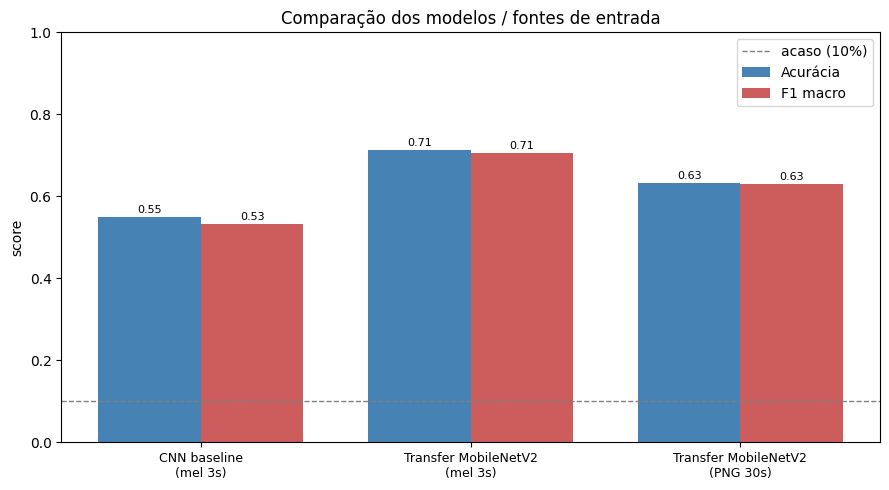

In [7]:
x = np.arange(len(order)); w = 0.38
acc = [results[k]["accuracy"] for k in order]
f1 = [results[k]["f1_macro"] for k in order]
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, acc, w, label="Acurácia", color="steelblue")
b2 = ax.bar(x + w/2, f1, w, label="F1 macro", color="indianred")
ax.axhline(0.1, ls="--", c="gray", lw=1, label="acaso (10%)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.set_title("Comparação dos modelos / fontes de entrada")
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 4. Conclusões

- **Melhor modelo:** a transferência de aprendizado (MobileNetV2 + extração de features)
  supera amplamente a CNN treinada do zero sobre os espectrogramas Mel de 3 s.
- **Fonte de entrada:** comparar o caminho librosa (3 s) com as PNGs prontas (30 s) — ver
  tabela acima. Diferenças refletem tanto a qualidade da entrada (espectrogramas limpos vs.
  imagens com eixos/margens) quanto a granularidade (3 s vs. 30 s) e o volume de amostras.
- **Limitações e ética:** divisão por música evita vazamento; o GTZAN tem falhas conhecidas
  (duplicatas, rótulos ruidosos) que limitam a validade externa; o classificador é
  acadêmico e não deve embasar decisões comerciais sem validação adicional.
- **Trabalhos futuros:** *fine-tuning* do backbone, voto majoritário por música (agregando os
  10 segmentos), *data augmentation* de áudio (*time/frequency masking*) e bases mais
  recentes e diversas.

Todos os resultados estão em `models/results.json`; os artefatos treinados em `models/`.